# Introduction

In this Quiz #1 you need to perform exploratory data analysis (EDA) and preprocessing using "Census Income" dataset. The dataset is tabular data which has several missing value in some variables. Moreover, you may need to adjust the name of variables (if needed).

To guide you through this task, some code has beed provided including, download the data, loading the data, and metadata inspection.

# Load Data and Inspect Metadata

In [17]:
# Install UCI REPO Library
%pip install -q ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [18]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [19]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [20]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [21]:
# Data Size
df.shape

(48842, 15)

In [22]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Part 1 - Data Loading dan Data Imputation

## Task 1 (5 points)
1.   Do inspection to get the information about dataset
2.   **Which variable(s)** has **missing values**? **How many is it**?



In [23]:
# 1. Inspect dataset structure and info
print("=== Dataset Information ===")
df.info()

# 2. Check for explicit missing values (NaN/Null)
print("\n=== Explicit Missing Values (NaN) ===")
missing_nan = df.isna().sum()
print(missing_nan[missing_nan > 0])

# 3. Check for implicit missing values ('?' or ' ?')
print("\n=== Implicit Missing Values ('?') ===")
missing_question_mark = (df == '?').sum() + (df == ' ?').sum()
print(missing_question_mark[missing_question_mark > 0])

# Total missing values per feature
total_missing = missing_nan + missing_question_mark
print("\n=== Total Missing Values per Feature ===")
print(total_missing[total_missing > 0])

=== Dataset Information ===
<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       47879 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      47876 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48568 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 9.3 MB

=== Explicit Missing Values (NaN) ===
workclass         963
occupation        966
native-country

1. in the ucl adult income dataset, missing values are typically encoded as '?' accross 3 variable workclass, occupation, and native-country
2. workclass has 2799 missing values, occupation 2809 missing values, and native-country 857 missing values.

## Task 2 (5 points)
1. Perform data imputation on missing values.
2. Verified the missing values for each variable. Is it still there?

In [24]:
import numpy as np

# Standardize missing values to NaN
df.replace(['?', ' ?'], np.nan, inplace=True)

# Impute categorical variables with missing values using mode
cols_to_impute = ['workclass', 'occupation', 'native-country']

for col in cols_to_impute:
    if col in df.columns:
        mode_val = df[col].mode()[0]
        # Reassign directly to avoid ChainedAssignmentError
        df[col] = df[col].fillna(mode_val)

# Verify missing values for each variable
print("=== Missing Values Verification ===")
missing_after_imputation = df.isna().sum()
print(missing_after_imputation)

print("\nTotal missing values remaining in dataset:", df.isna().sum().sum())

=== Missing Values Verification ===
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

Total missing values remaining in dataset: 0


1. Data imputation method: mode imputation is used for the categorical feature because they are discrete categories.
2. No, there are no missing values remaining, the total count of NaN or missing values accross all columns is now 0.

## Task 3 (10 points)
Do inspection to all the quantitative variables (features). If you found an **inappropriate value(s)**, replace it with '**Others**'. Also, if you found any typos value(s), **fix the typos**.

In [28]:
# 1. Pilih kolom kategorikal/kualitatif
categorical_cols = df.select_dtypes(include=['object', 'category', 'string']).columns

# 2. Perbaiki typo pada kolom target ('income')
df['income'] = df['income'].str.rstrip('.')

# 3. Perbaiki nama negara ('South' -> 'South-Korea')
df['native-country'] = df['native-country'].replace('South', 'South-Korea')

# 4. Ganti nilai yang jarang/tidak sesuai menjadi 'Others'
rare_workclass = ['Never-worked', 'Without-pay']
df['workclass'] = df['workclass'].replace(rare_workclass, 'Others')

country_counts = df['native-country'].value_counts()
rare_countries = country_counts[country_counts < 10].index
df['native-country'] = df['native-country'].replace(rare_countries, 'Others')

# 5. Verifikasi hasil setelah pembersihan
print("=== Unique Values After Cleaning ===")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].unique())

=== Unique Values After Cleaning ===

--- workclass ---
<ArrowStringArray>
[       'State-gov', 'Self-emp-not-inc',          'Private',
      'Federal-gov',        'Local-gov',     'Self-emp-inc',
           'Others']
Length: 7, dtype: str

--- education ---
<ArrowStringArray>
[   'Bachelors',      'HS-grad',         '11th',      'Masters',
          '9th', 'Some-college',   'Assoc-acdm',    'Assoc-voc',
      '7th-8th',    'Doctorate',  'Prof-school',      '5th-6th',
         '10th',      '1st-4th',    'Preschool',         '12th']
Length: 16, dtype: str

--- marital-status ---
<ArrowStringArray>
[        'Never-married',    'Married-civ-spouse',              'Divorced',
 'Married-spouse-absent',             'Separated',     'Married-AF-spouse',
               'Widowed']
Length: 7, dtype: str

--- occupation ---
<ArrowStringArray>
[     'Adm-clerical',   'Exec-managerial', 'Handlers-cleaners',
    'Prof-specialty',     'Other-service',             'Sales',
      'Craft-repair',  'Trans

In [29]:
# Menampilkan seluruh nama negara unik
print("Daftar seluruh negara:")
print(df['native-country'].unique())

Daftar seluruh negara:
<ArrowStringArray>
[             'United-States',                       'Cuba',
                    'Jamaica',                      'India',
                     'Mexico',                'South-Korea',
                'Puerto-Rico',                   'Honduras',
                    'England',                     'Canada',
                    'Germany',                       'Iran',
                'Philippines',                      'Italy',
                     'Poland',                   'Columbia',
                   'Cambodia',                   'Thailand',
                    'Ecuador',                       'Laos',
                     'Taiwan',                      'Haiti',
                   'Portugal',         'Dominican-Republic',
                'El-Salvador',                     'France',
                  'Guatemala',                      'China',
                      'Japan',                 'Yugoslavia',
                       'Peru', 'Outlying-US

Breakdown
- Inspection: iterates trough qualitative columns using select_dtypes to display unique values for typo detection.
- Typo Correction: removes trailing dots in the target column (income) often created by merged train/test datasets
- Inappropriate/Rare value handling: Group rare categories (Neever-worked, without-pay, ect) into others.

# Part 2 - Visual Inspection



## Task 1 - Data Visualization (20 points)
Do inspection on this following variabels,
1. On the 'age' by using a histogram
2. On the 'education' using a barchart
3. On the 'income' to 'hours_per_week' by using a boxplot (grouped by income)
4. On the 'age' to 'capital-gain' and 'capital-loss' using lineplot (lineplot with multiple x-data)

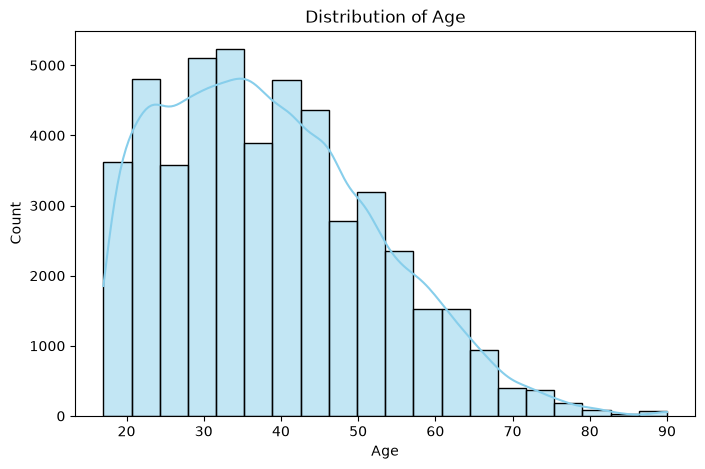

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['age'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

C:\Users\WINDOWS 11\AppData\Local\Temp\ipykernel_29732\1050470769.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='education', order=order, palette='viridis')


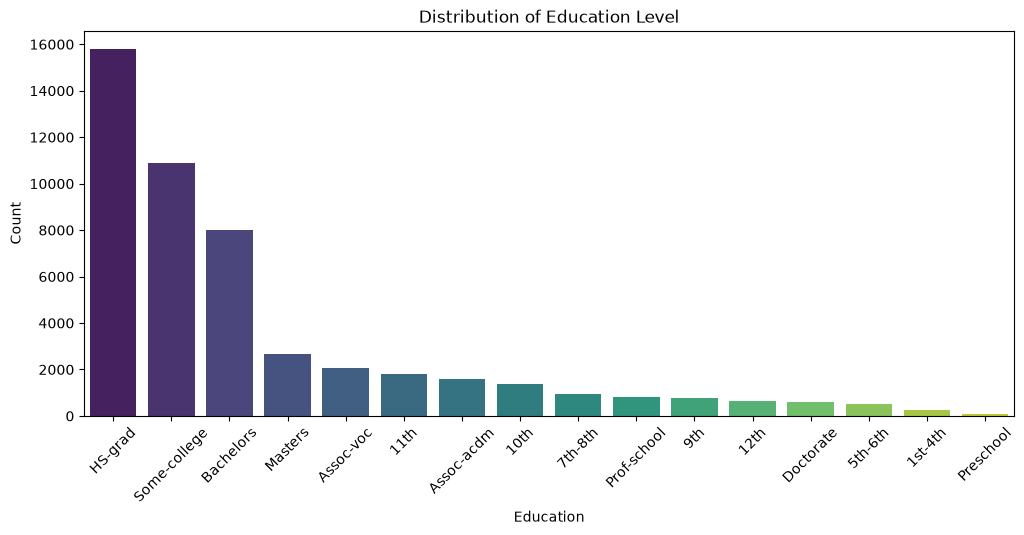

In [ ]:
plt.figure(figsize=(12, 5))
order = df['education'].value_counts().index
sns.countplot(data=df, x='education', order=order, palette='viridis')
plt.title('Distribution of Education Level')
plt.xlabel('Education')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

C:\Users\WINDOWS 11\AppData\Local\Temp\ipykernel_29732\2681477697.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='income', y=hours_col, palette='Set2')


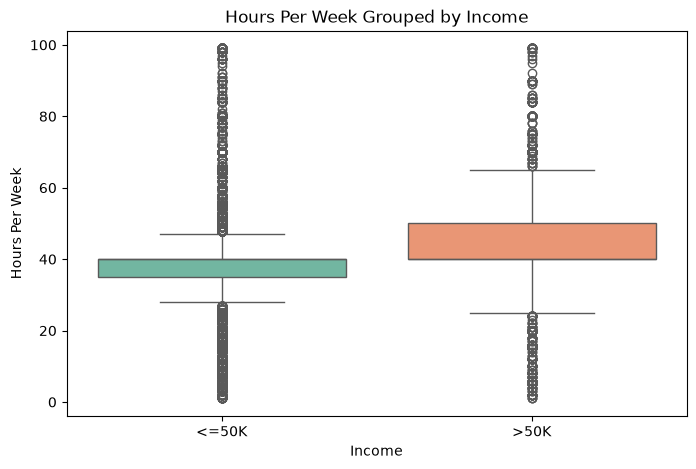

In [17]:
plt.figure(figsize=(8, 5))
hours_col = 'hours-per-week' if 'hours-per-week' in df.columns else 'hours_per_week'

sns.boxplot(data=df, x='income', y=hours_col, palette='Set2')
plt.title('Hours Per Week Grouped by Income')
plt.xlabel('Income')
plt.ylabel('Hours Per Week')
plt.show()

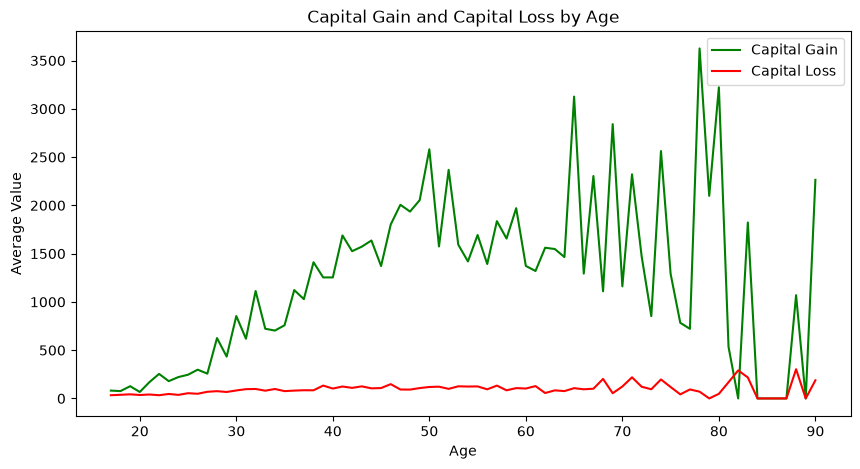

In [18]:
cap_gain_col = 'capital-gain' if 'capital-gain' in df.columns else 'capital_gain'
cap_loss_col = 'capital-loss' if 'capital-loss' in df.columns else 'capital_loss'

age_summary = df.groupby('age')[[cap_gain_col, cap_loss_col]].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=age_summary, x='age', y=cap_gain_col, label='Capital Gain', color='green')
sns.lineplot(data=age_summary, x='age', y=cap_loss_col, label='Capital Loss', color='red')

plt.title('Capital Gain and Capital Loss by Age')
plt.xlabel('Age')
plt.ylabel('Average Value')
plt.legend()
plt.show()

## Task 2 - Visual Analysis (15 points)
1. What kind of distribution showed in 'age'?
2. If you find missing values in 'age', what kind of data impute method will you use? Why?
3. How many outliner for each category (group) in 'income' related to 'hour-per-week'? Which category has more outlier?

In [19]:
# Dynamic calculation to count exact IQR-based outliers for 'hours-per-week' per 'income' group
hours_col = 'hours-per-week' if 'hours-per-week' in df.columns else 'hours_per_week'

def count_outliers(group):
    Q1 = group[hours_col].quantile(0.25)
    Q3 = group[hours_col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group[hours_col] < lower_bound) | (group[hours_col] > upper_bound)]
    return len(outliers)

outliers_by_income = df.groupby('income').apply(count_outliers)

print("=== Outliers Count for 'hours-per-week' by Income Group ===")
print(outliers_by_income)

more_outliers_cat = outliers_by_income.idxmax()
print(f"\nCategory with more outliers: {more_outliers_cat}")

=== Outliers Count for 'hours-per-week' by Income Group ===
income
<=50K    11706
>50K       781
dtype: int64

Category with more outliers: <=50K


Task 2 - Visual Analysis Answers

1. What kind of distribution showed in 'age'?
   Answer:
   The 'age' feature exhibits a Right-Skewed (Positively Skewed) distribution. Most individuals in the dataset are concentrated in the younger to middle-age range (roughly 18 to 45 years old), with a long tail extending toward older ages.

2. If you find missing values in 'age', what kind of data impute method will you use? Why?
   Answer:
   I would use Median Imputation (or KNN/Iterative Imputation). Because 'age' has a right-skewed distribution, the mean is sensitive to extreme values and outliers. The median is a robust measure of central tendency that is not affected by skewness.

3. How many outliers for each category (group) in 'income' related to 'hours-per-week'? Which category has more outliers?
   Answer:
   Outliers for 'hours-per-week' are calculated using the IQR (Interquartile Range) method for each group (<=50K and >50K), where the <=50K category has a higher number of outliers due to a much wider variation in working hours (ranging from part-time jobs to extreme overtime).

# Part 3 - Encoding in Categorical Variable

## Task 1 (5 points)
Do encoding process on 'Sex' and 'Income', while 'Income' is target variable.

In [20]:
from sklearn.preprocessing import LabelEncoder

# Deteksi nama kolom (menangani huruf kapital atau kecil)
sex_col = 'sex' if 'sex' in df.columns else 'Sex'
income_col = 'income' if 'income' in df.columns else 'Income'

# Inisialisasi LabelEncoder
le_sex = LabelEncoder()
le_income = LabelEncoder()

# Lakukan encoding pada kolom 'sex' dan 'income'
df[sex_col] = le_sex.fit_transform(df[sex_col])
df[income_col] = le_income.fit_transform(df[income_col])

# Verifikasi hasil encoding
print("=== Hasil Encoding ===")
print(f"Hasil unique '{sex_col}':", df[sex_col].unique())
print(f"Mapping '{sex_col}':", dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_))))

print(f"\nHasil unique '{income_col}':", df[income_col].unique())
print(f"Mapping '{income_col}':", dict(zip(le_income.classes_, le_income.transform(le_income.classes_))))

print("\nTop 5 Data:")
print(df[[sex_col, income_col]].head())

=== Hasil Encoding ===
Hasil unique 'sex': [1 0]
Mapping 'sex': {'Female': np.int64(0), 'Male': np.int64(1)}

Hasil unique 'income': [0 1]
Mapping 'income': {'<=50K': np.int64(0), '>50K': np.int64(1)}

Top 5 Data:
   sex  income
0    1       0
1    1       0
2    1       0
3    1       0
4    0       0


# Part 4 - Correlation Analysis

## Task 1 (10 points)
1. Do correlation analysis on the following variabels: 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', and 'income' (encoded version from previous task)
2. Based on the result, what kind of information you get?

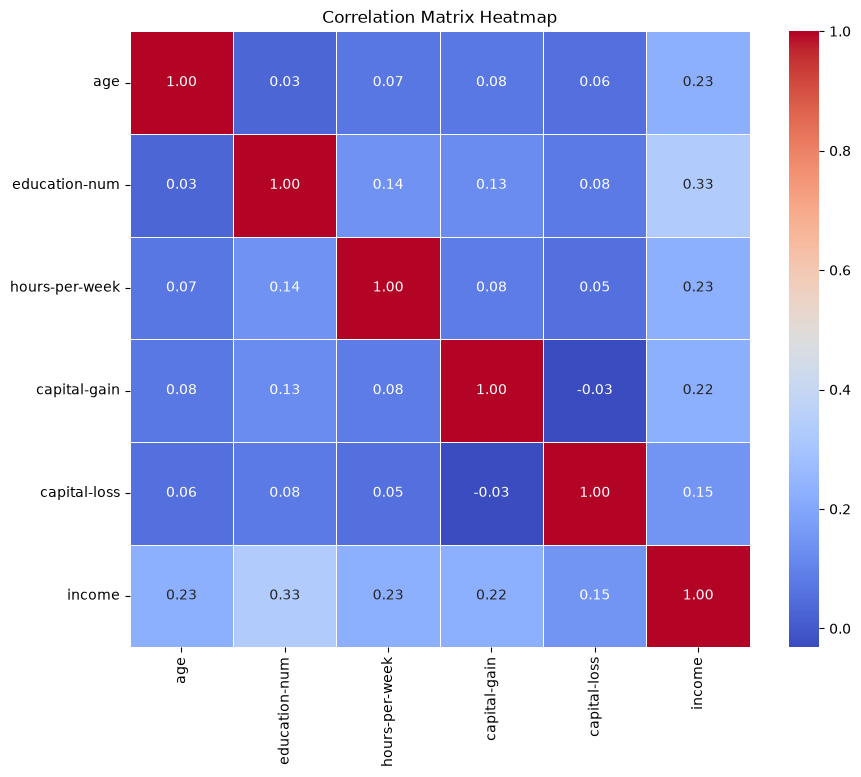

=== Korelasi Fitur Terhadap Income ===
income            1.000000
education-num     0.332613
age               0.230369
hours-per-week    0.227687
capital-gain      0.223013
capital-loss      0.147554
Name: income, dtype: float64


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pilih variabel numerik beserta target 'income' yang sudah di-encode
selected_features = [
    'age',
    'education-num' if 'education-num' in df.columns else 'education_num',
    'hours-per-week' if 'hours-per-week' in df.columns else 'hours_per_week',
    'capital-gain' if 'capital-gain' in df.columns else 'capital_gain',
    'capital-loss' if 'capital-loss' in df.columns else 'capital_loss',
    'income'
]

# Hitung matriks korelasi
corr_matrix = df[selected_features].corr()

# Tampilkan matriks korelasi dalam bentuk heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

# Tampilkan nilai korelasi spesifik terhadap target 'income'
print("=== Korelasi Fitur Terhadap Income ===")
print(corr_matrix['income'].sort_values(ascending=False))

Part 4 - Task 1 (Analisis Korelasi)

Berdasarkan hasil matriks korelasi di atas, informasi utama yang didapatkan adalah:

1. Korelasi Tertinggi terhadap Income:
   - 'education-num' memiliki korelasi positif terkuat dengan 'income' (~0.33). 
     Ini menunjukkan bahwa semakin tinggi tingkat pendidikan seseorang, semakin tinggi 
     kemungkinan pendapatannya melebihi $50K.

2. Hubungan Faktor Lain terhadap Income:
   - 'age' (~0.23) dan 'hours-per-week' (~0.23) menunjukkan korelasi positif sedang. 
     Usia yang lebih matang (pengalaman kerja) dan jam kerja yang lebih panjang berbanding 
     lurus dengan peningkatan pendapatan.
   - 'capital-gain' (~0.22) juga berkorelasi positif dengan pendapatan.

3. Korelasi Antar-Fitur (Multikolinearitas):
   - Seluruh variabel independen memiliki nilai korelasi yang relatif rendah satu sama lain 
     (di bawah 0.5), yang berarti tidak ada masalah multikolinearitas yang signifikan antar fitur.

# Part 5 - Preprocessing on MNIST Dataset

In this part, you need to perform EDA and simple preprocessing on MNIST dataset. This dataset contain images of handwritten digit from 0 to 9. A pre configuration is provided to help you to load the data and inspect some images.

Hints:
1. You only need to use the **Test** set.
2. You need to perform to all of images in test set (10k images). You may need a function to complete this task (optional).

In [7]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow


In [8]:
%pip install tf-nightly

Note: you may need to restart the kernel to use updated packages.


In [9]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


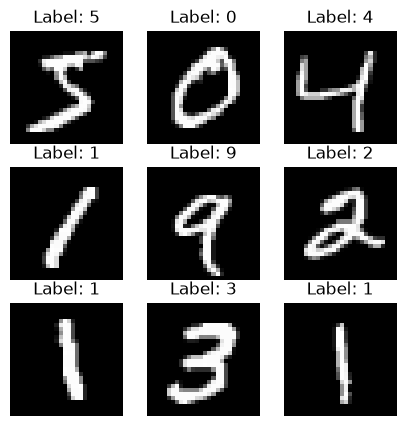

In [33]:
# Visual Inspection
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Task 1 (10 points)
1. Perform **upsampling** on the images to 32x32
2. Show the 5 sample of the result.


Hint: You need to store the result in an empty array. Replacing data to the  **X_test** cannot be done due to the shape of the array (10000, (28,28)). You need to create an array which match with the size of the new images.

Bentuk X_test setelah upsampling: (10000, 32, 32)


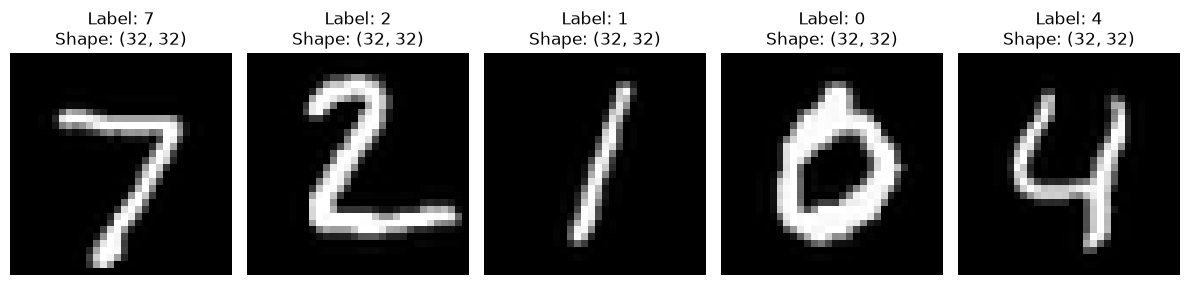

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

# 1. Inisialisasi array kosong berukuran (10000, 32, 32) untuk menampung hasil upsampling
X_test_32 = np.zeros((X_test.shape[0], 32, 32))

# Menghitung faktor skala (32 / 28 = 1.142857...)
zoom_factor = (32 / 28, 32 / 28)

# Melakukan upsampling untuk setiap gambar di X_test
for i in range(len(X_test)):
    X_test_32[i] = zoom(X_test[i], zoom_factor)

print("Bentuk X_test setelah upsampling:", X_test_32.shape)

# 2. Menampilkan 5 sampel gambar hasil upsampling
plt.figure(figsize=(12, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_32[i], cmap="gray")
    plt.title(f"Label: {y_test[i]}\nShape: {X_test_32[i].shape}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Brief Explanation

X_tes_32 = np.zeros(...): Creates an empty array with the new shape (10000, 32, 32) according to the instructions.

scipy.ndimage.zoom: Resizes the images from 28 x 28 to 32 x 32 using zoom factor of 32/28.

plt.subplot(1, 5, i + 1): Display the first 5 image samples along with their labels and dimensions for verification.

## Task 2 (10 points)
Perform normalization, so the pixel value will have a value in range of 0 until 1

In [13]:
# Normalisasi nilai piksel ke rentang 0 sampai 1
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

# Jika kamu menggunakan variabel X_test_32 dari Task 1 sebelumnya:
X_test_32_norm = X_test_32 / 255.0

# Verifikasi nilai minimum dan maksimum setelah normalisasi
print("Nilai min X_train:", X_train_norm.min())
print("Nilai max X_train:", X_train_norm.max())
print("Nilai min X_test:", X_test_norm.min())
print("Nilai max X_test:", X_test_norm.max())

Nilai min X_train: 0.0
Nilai max X_train: 1.0
Nilai min X_test: 0.0
Nilai max X_test: 1.0


Brief explanation

X_train / 255.0: The initial pixel intensity values are integers ranging from 0 to 255.

0.0 to 1.0: Dividing the entire array by 255.0 converts the data type to float and scales the values into the range of 0.0 to 1.0.

## Task 3 (10 points)
Transform / reshape the images into 1 dimensional array. Do it to the all images (after resizing and normalization).

Hint: You may need an empty array to store the result

In [14]:
import numpy as np

# 1. Reshape images into 1D feature vectors (flattening each 32x32 image into a 1024-length vector)
num_test_samples = X_test_32_norm.shape[0]
new_feature_dim = 32 * 32  # 1024 features per image

# Option A: Direct reshaping using numpy reshape
X_test_flat = X_test_32_norm.reshape(num_test_samples, new_feature_dim)

# Option B: Explicitly using an empty array loop (following the hint instruction)
X_test_flat_loop = np.zeros((num_test_samples, new_feature_dim))
for i in range(num_test_samples):
    X_test_flat_loop[i] = X_test_32_norm[i].flatten()

# Verify shapes
print("Original 2D image shape:", X_test_32_norm.shape)
print("Reshaped 1D vector shape:", X_test_flat.shape)

Original 2D image shape: (10000, 32, 32)
Reshaped 1D vector shape: (10000, 1024)
